In [1]:
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

D:\Projects\4_Sem\AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используемое устройство: cpu


In [2]:
# Датасет emotion
dataset = load_dataset("emotion")

# Показываем размеры split-частей
print("Размеры частей датасета:")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

# Названия классов
label_names = dataset['train'].features['label'].names
print(f"\nКлассы эмоций: {label_names}")

# Примеры текстов и меток
print("\nПримеры текстов и меток:")
for i in range(5):
    example = dataset['train'][i]
    print(f"{i+1}. Текст: {example['text'][:100]}...")
    print(f"   Метка: {label_names[example['label']]}\n")
    print(f"Классифицируем эмоции")

Размеры частей датасета:
Train: 16000
Validation: 2000
Test: 2000

Классы эмоций: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов и меток:
1. Текст: i didnt feel humiliated...
   Метка: sadness

2. Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
   Метка: sadness

3. Текст: im grabbing a minute to post i feel greedy wrong...
   Метка: anger

4. Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property...
   Метка: love

5. Текст: i am feeling grouchy...
   Метка: anger



In [3]:
# Загружаем токенизатор BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Выбираем несколько текстов для демонстрации токенизации
sample_texts = [
    "i am feeling very happy today",
    "this movie is terrible and boring",
    "i love spending time with my family",
    "the service was absolutely horrible",
    "what a wonderful surprise"
]

# Демонстрация токенизации
for i, text in enumerate(sample_texts):
    print(f"\nПример {i+1}")
    print(f"Исходный текст: {text}")
    
    # Токенизация
    tokens = tokenizer.tokenize(text)
    print(f"Токены: {tokens}")
    
    # Преобразование в input_ids
    encoding = tokenizer(text, return_tensors="pt")
    print(f"input_ids: {encoding['input_ids'][0].tolist()}")
    print(f"attention_mask: {encoding['attention_mask'][0].tolist()}")
    
    # Special tokens
    print(f"Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (паддинг)")

# Padding и truncation
print("\nPadding и Truncation")
encoded_padded = tokenizer(sample_texts, padding=True, truncation=True, max_length=10, return_tensors="pt")
print(f"После padding (макс длина 10):")
print(f"Размер input_ids: {encoded_padded['input_ids'].shape}")
print(f"Пример input_ids с padding: {encoded_padded['input_ids'][0].tolist()}")


Пример 1
Исходный текст: i am feeling very happy today
Токены: ['i', 'am', 'feeling', 'very', 'happy', 'today']
input_ids: [101, 1045, 2572, 3110, 2200, 3407, 2651, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (паддинг)

Пример 2
Исходный текст: this movie is terrible and boring
Токены: ['this', 'movie', 'is', 'terrible', 'and', 'boring']
input_ids: [101, 2023, 3185, 2003, 6659, 1998, 11771, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (паддинг)

Пример 3
Исходный текст: i love spending time with my family
Токены: ['i', 'love', 'spending', 'time', 'with', 'my', 'family']
input_ids: [101, 1045, 2293, 5938, 2051, 2007, 2026, 2155, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (паддинг)

Пример 4
Исходный текст: the service was absolutely horrible
Токены: ['the', 'service', 'was', 'absolutely', 'horrible']
input_ids: [101, 199

In [4]:
# Загружаем предобученную модель для sentiment analysis
sentiment_model = AutoModelForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
sentiment_tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
sentiment_model.to(device)

# Тестовые тексты
test_texts = [
    "This product is absolutely amazing!",
    "I'm so disappointed with the quality",
    "It's okay, nothing special",
    "Best purchase ever!",
    "Waste of money"
]

print("Инференс готовой модели (sentiment analysis от 1 до 5 звезд):\n")
for text in test_texts:
    inputs = sentiment_tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = sentiment_model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item() + 1  # +1 потому что классы 0-4
        confidence = predictions[0][predicted_class-1].item()
    
    print(f"Текст: {text}")
    print(f"Предсказание: {predicted_class} звезд (confidence: {confidence:.3f})\n")

print("Анализ: Эта модель предсказывает рейтинг от 1 до 5 звезд, что не совсем подходит для классификации эмоций (радость, грусть, гнев и т.д.). Для задачи классификации эмоций нужна модель, обученная именно на эмоциональных данных.")

Инференс готовой модели (sentiment analysis от 1 до 5 звезд):

Текст: This product is absolutely amazing!
Предсказание: 5 звезд (confidence: 0.947)

Текст: I'm so disappointed with the quality
Предсказание: 2 звезд (confidence: 0.556)

Текст: It's okay, nothing special
Предсказание: 3 звезд (confidence: 0.831)

Текст: Best purchase ever!
Предсказание: 5 звезд (confidence: 0.971)

Текст: Waste of money
Предсказание: 1 звезд (confidence: 0.775)

Анализ: Эта модель предсказывает рейтинг от 1 до 5 звезд, что не совсем подходит для классификации эмоций (радость, грусть, гнев и т.д.). Для задачи классификации эмоций нужна модель, обученная именно на эмоциональных данных.


In [5]:
# Выбираем BERT-подобную модель для классификации эмоций
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_names))
model.to(device)

# Функция токенизации для датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Токенизируем датасет
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Удаляем ненужные колонки
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Датасет готов для обучения:")
print(f"Train: {len(tokenized_dataset['train'])}")
print(f"Validation: {len(tokenized_dataset['validation'])}")
print(f"Test: {len(tokenized_dataset['test'])}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 2000/2000 [00:00<00:00, 18320.66 examples/s]

Датасет готов для обучения:
Train: 16000
Validation: 2000
Test: 2000


In [8]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": accuracy, "f1_macro": f1}

# Отключаем torch_compile для избежания ошибки
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="./logs",
    logging_steps=100,
    seed=42,
    report_to="none",
    torch_compile=False,
)

# Создаем Trainer без tokenizer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# Обучение модели
print("Начинаем fine-tuning...")
trainer.train()

print("\nFine-tuning завершен!")

Начинаем fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.221200,0.190731,0.929000,0.905611
2,0.107800,0.161519,0.938000,0.913513
3,0.075800,0.171703,0.938000,0.915333


D:\Projects\4_Sem\AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
D:\Projects\4_Sem\AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Fine-tuning завершен!


In [9]:
# Оценка на validation для выбора лучшего варианта
val_results = trainer.evaluate(tokenized_dataset["validation"])
print("Результаты на validation:")
print(f"Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"F1-macro: {val_results['eval_f1_macro']:.4f}")

# Финальная оценка на test
test_results = trainer.evaluate(tokenized_dataset["test"])
print("\nФинальные результаты на test:")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1-macro: {test_results['eval_f1_macro']:.4f}")

D:\Projects\4_Sem\AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Результаты на validation:
Accuracy: 0.9380
F1-macro: 0.9153


D:\Projects\4_Sem\AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Финальные результаты на test:
Accuracy: 0.9215
F1-macro: 0.8717


D:\Projects\4_Sem\AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


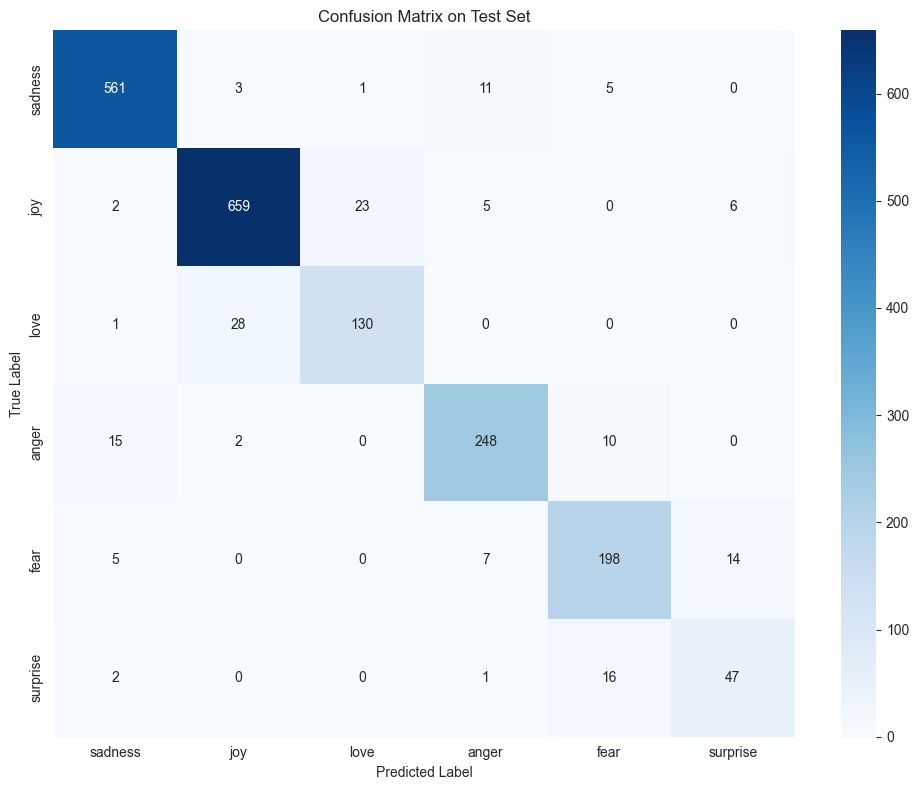


Примеры предсказаний модели:
✓ Текст: i feel so dirty but after spending a day at the mk show me and a buddy decided w...
   True: sadness | Pred: sadness | Confidence: 0.999

✗ Текст: i could feel his breath on me and smell the sweet scent of him...
   True: joy | Pred: love | Confidence: 0.959

✓ Текст: i just want to feel loved by you...
   True: love | Pred: love | Confidence: 0.998

✓ Текст: i have felt the need to write out my sometimes anxious feelings impatient though...
   True: anger | Pred: anger | Confidence: 0.997

✗ Текст: at a party i met a girl who drew me to her...
   True: anger | Pred: fear | Confidence: 0.824

✗ Текст: i feel this strange sort of liberation...
   True: surprise | Pred: fear | Confidence: 0.578

✓ Текст: i remember feeling thrilled to use my nursing skills relieved that i could have ...
   True: joy | Pred: joy | Confidence: 0.999

✓ Текст: i always feel sympathetic for those that do as well because life can be really h...
   True: love | Pred: love

In [10]:
# Получаем предсказания для test
predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Строим матрицу ошибок
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Примеры предсказаний
print("\nПримеры предсказаний модели:")
sample_indices = np.random.choice(len(tokenized_dataset["test"]), 10, replace=False)
sample_predictions = []

for idx in sample_indices:
    original_text = dataset["test"][idx]["text"]
    true_label = label_names[true_labels[idx]]
    pred_label = label_names[pred_labels[idx]]
    
    # Получаем confidence
    probs = torch.softmax(torch.tensor(predictions.predictions[idx]), dim=-1)
    confidence = probs[pred_labels[idx]].item()
    
    sample_predictions.append({
        "text": original_text,
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": confidence
    })
    
    status = "✓" if true_label == pred_label else "✗"
    print(f"{status} Текст: {original_text[:80]}...")
    print(f"   True: {true_label} | Pred: {pred_label} | Confidence: {confidence:.3f}\n")

# Сохраняем predictions в CSV
sample_predictions_df = pd.DataFrame(sample_predictions)
sample_predictions_df.to_csv('artifacts/sample_predictions.csv', index=False)

In [11]:
print("Анализ ошибок модели\n")

# Находим все ошибочные предсказания
errors = []
for i in range(len(tokenized_dataset["test"])):
    if pred_labels[i] != true_labels[i]:
        errors.append({
            "text": dataset["test"][i]["text"],
            "true": label_names[true_labels[i]],
            "pred": label_names[pred_labels[i]],
            "confidence": torch.softmax(torch.tensor(predictions.predictions[i]), dim=-1)[pred_labels[i]].item()
        })

print(f"Всего ошибок: {len(errors)} из {len(tokenized_dataset['test'])} ({len(errors)/len(tokenized_dataset['test'])*100:.1f}%)\n")

# Показываем наиболее частые ошибки
from collections import Counter
error_pairs = Counter([(e['true'], e['pred']) for e in errors])
print("Наиболее частые ошибки:")
for (true, pred), count in error_pairs.most_common(5):
    print(f"  {true} → {pred}: {count} раз")

print("\nПримеры ошибок модели:")
for i, error in enumerate(errors[:5]):
    print(f"\n{i+1}. Текст: {error['text']}")
    print(f"   True: {error['true']} | Pred: {error['pred']} | Confidence: {error['confidence']:.3f}")

print("\nАнализ: Модель чаще всего путает эмоции, которые семантически близки:")
print("- sadness и fear могут быть перепутаны (оба связаны с негативными переживаниями)")
print("- joy и love (позитивные эмоции)")
print("- anger может быть сложно отличить от sadness в некоторых контекстах")
print("Для улучшения качества можно увеличить размер обучающей выборки или использовать более сложную модель.")

Анализ ошибок модели

Всего ошибок: 157 из 2000 (7.8%)

Наиболее частые ошибки:
  love → joy: 28 раз
  joy → love: 23 раз
  surprise → fear: 16 раз
  anger → sadness: 15 раз
  fear → surprise: 14 раз

Примеры ошибок модели:

1. Текст: i don t feel particularly agitated
   True: fear | Pred: anger | Confidence: 0.737

2. Текст: i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change
   True: anger | Pred: sadness | Confidence: 0.607

3. Текст: i feel a bit stressed even though all the things i have going on are fun
   True: anger | Pred: sadness | Confidence: 0.550

4. Текст: i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird
   True: surprise | Pred: fear | Confidence: 0.574

5. Текст: i was feeling weird the other day and it went away about minutes after i took my metformin
   True: fear | Pred: surprise | Confidence: 0.500

Анализ: Модель чаще вс